<h1>Trabalho 2 de ARQ - G13</h1>

<h1>Atividade 02 - melhorar o desempenho de RP em conjunto de dados existentes</h1>
<p>A atividade 02 visa trabalhar com um conjunto de dados pré-construído, onde as opções que o desenvolvedor tem, são de aplicar as técnicas de pré-processamento abaixo relacionadas:</p>
<ul><li>Seleção</li>
<li>Limpeza</li>
<li>Codificação</li>
<li>Enriquecimento</li>
<li>Normalização</li>
<li>Construção de Atributos</li>
<li>Correção de Prevalência</li>
<li>Partição do Conjunto de Dados</li>
</ul>
<p>Busque uma base de dados na UCI Machine Learning que seja indicada para problemas de classificação. (<a target="_blank" href="https://archive.ics.uci.edu/datasets">https://archive.ics.uci.edu/datasets</a>)</p>



<p>Nossa opção foi pela base "Adult Census Income", cujo objetivo é predizer se o valor de income é maior que 50k</p>

## 01 - Carregar a base a partir da URL


In [25]:
# Hyperparametros
RAND_STATE = 13 # em homenagem ao Grupo!!
TEST_SIZE = 0.2 # 20% do Dataset para teste

In [2]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
  
# fetch dataset 
adult = fetch_ucirepo(id=2) 
  
# data (as pandas dataframes) 
df = pd.concat([adult.data.features, adult.data.targets], axis=1, ignore_index=False)

# metadata 
#print(adult.metadata) 
  
# variable information 
print(adult.variables) 


              name     role         type      demographic  \
0              age  Feature      Integer              Age   
1        workclass  Feature  Categorical           Income   
2           fnlwgt  Feature      Integer              NaN   
3        education  Feature  Categorical  Education Level   
4    education-num  Feature      Integer  Education Level   
5   marital-status  Feature  Categorical            Other   
6       occupation  Feature  Categorical            Other   
7     relationship  Feature  Categorical            Other   
8             race  Feature  Categorical             Race   
9              sex  Feature       Binary              Sex   
10    capital-gain  Feature      Integer              NaN   
11    capital-loss  Feature      Integer              NaN   
12  hours-per-week  Feature      Integer              NaN   
13  native-country  Feature  Categorical            Other   
14          income   Target       Binary           Income   

                       

In [3]:
df_bckp = df.copy()

In [4]:
# ponto de restart
df = df_bckp.copy()

## 02 - Limpeza

In [5]:
print(f'\nDimensões do Dataset: {df.shape[0]} linhas x {df.shape[1]} colunas\n')


Dimensões do Dataset: 48842 linhas x 15 colunas



In [6]:
# Converte '?' em NaN
df = df.replace("?", np.nan)

In [7]:
# remove ponto final da coluna income ##bug##
df["income"] = df["income"].str.replace('.', '', regex=False)

In [8]:
print("=== Valores faltantes por coluna ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Valores Faltantes': missing, 'Percentual (%)': missing_pct})
print(missing_df[missing_df['Valores Faltantes'] > 0])

=== Valores faltantes por coluna ===
                Valores Faltantes  Percentual (%)
workclass                    2799            5.73
occupation                   2809            5.75
native-country                857            1.75


In [9]:
# Tratativa: Remoção das linhas com valores em branco
print(f'=== Verificação de linhas com NaN ===')
print(f'\nLinhas antes da limpeza: {len(df)}')
df = df.dropna(how='any')
print(f'Linhas depois da limpeza: {len(df)}')

=== Verificação de linhas com NaN ===

Linhas antes da limpeza: 48842
Linhas depois da limpeza: 45222


In [10]:
# Verifica se existe linhas duplicadas
print(f'=== Verificação de Dados Duplicados ===')

duplicadas = df.duplicated().sum()
print(f'Total de linhas duplicadas: {duplicadas:,}')

# remoção de linhas duplicadas
if duplicadas > 0:
  print("\nIndice das linhas duplicadas:")
  print(df[df.duplicated(keep=False)].index.values)
  df = df.drop_duplicates()
  print(f'\nLinhas após remoção de duplicatas: {len(df):}')
else:
  print('\nNenhuma linha duplicata encontrada. Nenhuma ação necessária.')

=== Verificação de Dados Duplicados ===
Total de linhas duplicadas: 47

Indice das linhas duplicadas:
[ 2195  2303  3118  3445  3917  4325  4767  4881  4940  5104  5579  5805
  5842  6990  7053  7920  8080  8679  9171  9371  9841 10367 11631 11965
 13084 14581 14690 15059 15189 16297 16846 17040 17673 17867 17916 18698
 19567 20486 20567 21103 21318 21490 21875 21974 22249 22300 22367 22494
 24667 25624 25684 25872 26313 27920 28230 28522 28846 29157 30345 30845
 31993 32404 33049 33425 33880 34229 34415 36461 36713 38343 38468 39017
 39582 39911 41810 42386 43387 43484 43750 43773 44307 45049 46065 46409
 46714 46869 46959 47048 47399 47884 48521]

Linhas após remoção de duplicatas: 45175


In [ ]:
# Converte as colunas onde os valores só possuem duas classes
df['sex'] = df['sex'].map({
    "Male": 1,
    "Female": 0
}).astype(int)

df['income'] = df['income'].map({
    "<=50K": 0,
    ">50K": 1
}).astype(int)

## 03 - Análise exploratória de dados

In [12]:
# Lista as colunas por tipo
colunas_numericas = df.select_dtypes(include="number").columns.tolist()

colunas_categoricas = df.select_dtypes(exclude="number").columns.tolist()

print("** Lista de colunas numéricas **")
for elemento in colunas_numericas:
    print(elemento)
    
print("\n** Lista de colunas categóricas **")
for elemento in colunas_categoricas:
    print(elemento)

** Lista de colunas numéricas **
age
fnlwgt
education-num
sex
capital-gain
capital-loss
hours-per-week
income

** Lista de colunas categóricas **
workclass
education
marital-status
occupation
relationship
race
native-country


<p>Análise das variáveis numéricas</p>

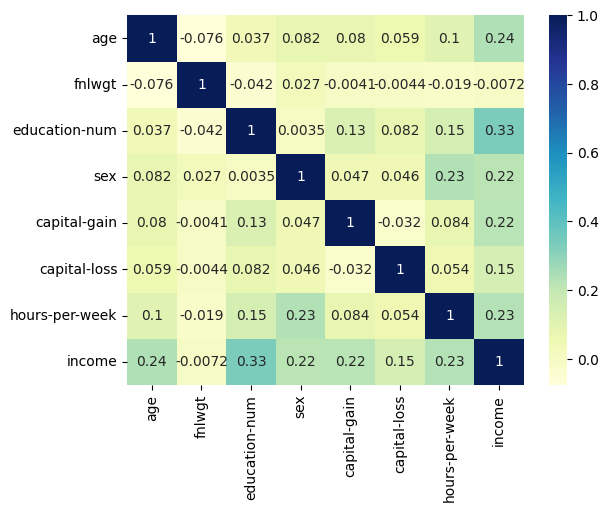

In [13]:
# Análise das variáveis numéricas
import seaborn as sns
import matplotlib.pyplot as plt

# Calcular a correlação das variáveis numéricas
co_mtx = df.corr(numeric_only=True)

# Mostra mapa de correlação das variáveis numéricas
sns.heatmap(co_mtx, cmap="YlGnBu", annot=True)
plt.show()

<p>A Variável 'fnlwgt' não tem significância com o target ('income'). A variável 'capital-loss' possui baixa relação, porém vamos analisar um pouco mais sua composição.</p>

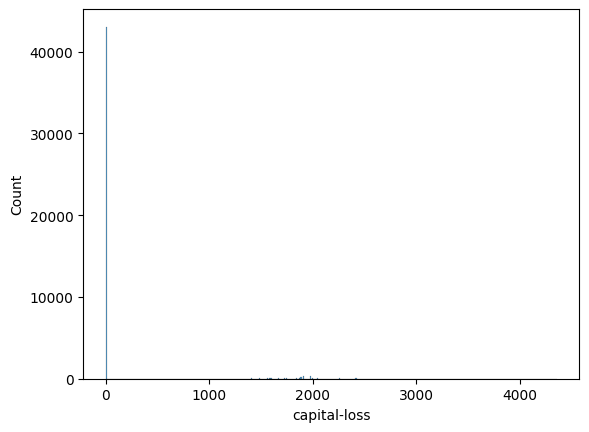

In [14]:
# Mostra histograma da variável 'capital-loss'
sns.histplot(df['capital-loss'])
plt.show()

In [15]:
# Apresenta uma grande concentração de amostras em torno de zero.
# vamos remover 'fnlwgt' e 'capital-loss' do dataset

df = df.drop(['fnlwgt', 'capital-loss'], axis=1)

<p>Análise das variáveis categóricas</p>

In [16]:
# A coluna 'education' pode ser removida em favor da coluna 'education_num' que representa o número de anos de educação
df = df.drop(['education'], axis=1)

In [17]:
# Verifica a quantidades de classes das colunas descritivas
df.select_dtypes(include="str").nunique().sort_values(ascending=False)

native-country    41
occupation        14
marital-status     7
workclass          7
relationship       6
race               5
dtype: int64

In [18]:
# Verifica a cardinalidade de 'native-country' pois é a variável com maior número de classes
freq = df['native-country'].value_counts()
print(freq)

native-country
United-States                 41256
Mexico                          895
Philippines                     282
Germany                         193
Puerto-Rico                     175
Canada                          163
India                           147
El-Salvador                     147
Cuba                            133
England                         119
China                           113
Jamaica                         103
South                           101
Italy                           100
Dominican-Republic               97
Japan                            89
Guatemala                        84
Vietnam                          83
Columbia                         82
Poland                           81
Haiti                            69
Portugal                         62
Iran                             56
Taiwan                           55
Greece                           49
Nicaragua                        48
Peru                             45
Ecuador      

In [19]:
# Com a predominância de uma classe, vamos converter em apenas duas classes

# obter a classe dominante
dominante = df['native-country'].value_counts().idxmax()

# converte para binário
df['native-country'] = (df['native-country'] == dominante).astype(int)
    

In [20]:
# Vamos verificar a distribuição de classes em 'occupation'
freq = df['occupation'].value_counts()
print(freq)

occupation
Craft-repair         6010
Prof-specialty       6001
Exec-managerial      5980
Adm-clerical         5535
Sales                5405
Other-service        4805
Machine-op-inspct    2965
Transport-moving     2316
Handlers-cleaners    2045
Farming-fishing      1475
Tech-support         1419
Protective-serv       975
Priv-house-serv       230
Armed-Forces           14
Name: count, dtype: int64


In [21]:
# Vamos tratar como Other-service, todas as classes abaixo de 5000
rare = freq[freq < 5000].index

df["occupation"] = (
    df["occupation"]
    .replace(rare, "Other-service")
)

In [22]:
# Verifica a quantidades de classes das colunas descritivas remanescentes
df.select_dtypes(include="str").nunique().sort_values(ascending=False)

workclass         7
marital-status    7
occupation        6
relationship      6
race              5
dtype: int64

## 04 - Codificação

In [23]:
#1 - obtem lista de colunas de acordo com o tipo (atualizada)
colunas_numericas = df.select_dtypes(include="number").columns.tolist()
colunas_categoricas = df.select_dtypes(exclude="number").columns.tolist()

#2 Converte colunas categoricas em hot-encoders
workclass_dummies = pd.get_dummies(df['workclass'], prefix='wk', dtype=int, drop_first=False)

marital_status_dummies = pd.get_dummies(df['marital-status'], prefix='ms', dtype=int, drop_first=False)

occupation_dummies = pd.get_dummies(df['occupation'], prefix='occ', dtype=int, drop_first=False)

relationship_dummies = pd.get_dummies(df['relationship'], prefix='rs', dtype=int, drop_first=False)

race_dummies = pd.get_dummies(df['race'], prefix='rc', dtype=int, drop_first=False)

#3 remove colunas categoricas
df = df.drop(colunas_categoricas, axis=1)

#4 concatena com as colunas "encodadas"
df = pd.concat([df[colunas_numericas], workclass_dummies, marital_status_dummies, occupation_dummies,
               relationship_dummies, race_dummies], axis=1)


## 05 - Partição dos dados originais

In [24]:
# Separa features de target
y = df['income']
X = df.drop(['income'], axis=1)

In [26]:
from sklearn.model_selection import train_test_split

# Vamos particionar o dataset em 80% para treinamento e 20% para teste
X_treino_orig, X_teste_orig, y_treino_orig, y_teste_orig = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RAND_STATE)

## 06 - Modelo

In [27]:
from sklearn import svm
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

#model = svm.SVC()  #algoritmo escolhido
model = svm.LinearSVC()


In [28]:
# Treino do modelo sem tratamento
model.fit(X_treino_orig, y_treino_orig)

# predição com os mesmos dados usados para treinar
y_hat_treino_orig = model.predict(X_treino_orig)

cm_orig_train = confusion_matrix(y_treino_orig, y_hat_treino_orig)
print('Matriz de confusão - com os dados ORIGINAIS usados no TREINAMENTO')
print(cm_orig_train)
print(classification_report(y_treino_orig, y_hat_treino_orig))

# predição com os mesmos dados usados para testar
print('Matriz de confusão - com os dados ORIGINAIS usados para TESTES')
y_hat_teste_orig = model.predict(X_teste_orig)
cm_orig_test = confusion_matrix(y_teste_orig, y_hat_teste_orig)
print(cm_orig_test)
print(classification_report(y_teste_orig, y_hat_teste_orig))

Matriz de confusão - com os dados ORIGINAIS usados no TREINAMENTO
[[25444  1768]
 [ 3884  5044]]
              precision    recall  f1-score   support

           0       0.87      0.94      0.90     27212
           1       0.74      0.56      0.64      8928

    accuracy                           0.84     36140
   macro avg       0.80      0.75      0.77     36140
weighted avg       0.84      0.84      0.84     36140

Matriz de confusão - com os dados ORIGINAIS usados para TESTES
[[6312  449]
 [ 981 1293]]
              precision    recall  f1-score   support

           0       0.87      0.93      0.90      6761
           1       0.74      0.57      0.64      2274

    accuracy                           0.84      9035
   macro avg       0.80      0.75      0.77      9035
weighted avg       0.83      0.84      0.83      9035



In [29]:
# Avaliação da importancia das variáveis
importance = pd.Series(
    np.abs(model.coef_[0]),
    index=X.columns
).sort_values(ascending=False)

print(importance)

wk_Self-emp-not-inc         0.447386
rs_Own-child                0.440961
ms_Never-married            0.434803
occ_Other-service           0.420062
rs_Unmarried                0.385923
rs_Not-in-family            0.347230
rs_Other-relative           0.340983
rc_Black                    0.339852
occ_Craft-repair            0.322469
rc_Amer-Indian-Eskimo       0.311085
ms_Divorced                 0.307231
wk_State-gov                0.296681
occ_Adm-clerical            0.295775
ms_Widowed                  0.285778
rc_Asian-Pac-Islander       0.280336
rc_White                    0.268541
ms_Separated                0.258878
wk_Local-gov                0.224194
rs_Wife                     0.216137
wk_Private                  0.213424
sex                         0.206500
occ_Sales                   0.204561
rc_Other                    0.204021
ms_Married-spouse-absent    0.179261
wk_Self-emp-inc             0.157360
occ_Prof-specialty          0.120149
rs_Husband                  0.104875
e

## 07 - Normalização

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

In [31]:
# Vamos listar as colunas que necessitam padronizar (contínuas) e as que não devem ser padronizadas (binárias)

col_continuas = X.columns[(X.dropna().nunique() > 2)].to_list()
col_binarias = X.columns[(X.dropna().nunique() == 2)].tolist()

In [32]:
# Cria um preprocessamento para transformar apenas as variáveis contínuas e passar as binárias
processamento_X = ColumnTransformer(
    transformers=[
        ("cont", StandardScaler(), col_continuas),
        ("bin", "passthrough", col_binarias)
    ]
)


In [33]:
X_transformed = processamento_X.fit_transform(X)

In [34]:
# Vamos particionar o dataset em 80% para treinamento e 20% para teste
X_treino_norm, X_teste_norm, y_treino, y_teste = train_test_split(
    X_transformed, y, test_size=TEST_SIZE, random_state=RAND_STATE)

## 08 - Modelo com dados normalizados

In [35]:
# Treino do modelo com dados normalizados
model.fit(X_treino_norm, y_treino)

# predição com os mesmos dados usados para treinar
y_hat_treino_norm = model.predict(X_treino_norm)

cm_norm_train = confusion_matrix(y_treino, y_hat_treino_norm)
print('Matriz de confusão - com os dados NORMALIZADOS usados no TREINAMENTO')
print(cm_norm_train)
print(classification_report(y_treino, y_hat_treino_norm))

# predição com os mesmos dados usados para testar
print('Matriz de confusão - com os dados NORMALIZADOS usados para TESTES')
y_hat_teste_norm = model.predict(X_teste_norm)
cm_norm_test = confusion_matrix(y_teste, y_hat_teste_norm)
print(cm_norm_test)
print(classification_report(y_teste, y_hat_teste_norm))

Matriz de confusão - com os dados NORMALIZADOS usados no TREINAMENTO
[[25415  1797]
 [ 3838  5090]]
              precision    recall  f1-score   support

           0       0.87      0.93      0.90     27212
           1       0.74      0.57      0.64      8928

    accuracy                           0.84     36140
   macro avg       0.80      0.75      0.77     36140
weighted avg       0.84      0.84      0.84     36140

Matriz de confusão - com os dados NORMALIZADOS usados para TESTES
[[6299  462]
 [ 968 1306]]
              precision    recall  f1-score   support

           0       0.87      0.93      0.90      6761
           1       0.74      0.57      0.65      2274

    accuracy                           0.84      9035
   macro avg       0.80      0.75      0.77      9035
weighted avg       0.83      0.84      0.83      9035



In [36]:
from sklearn.inspection import permutation_importance

# Calcula a importancia
result = permutation_importance(
    model,
    X_teste_norm,
    y_teste,
    n_repeats=2,
    random_state=RAND_STATE,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': result.importances_mean
}).sort_values('importance', ascending=False)



print(importance_df)

                     feature  importance
1              education-num    0.038960
2                        sex    0.034256
15     ms_Married-civ-spouse    0.012286
17          ms_Never-married    0.009297
23         occ_Other-service    0.008024
3               capital-gain    0.004925
4             hours-per-week    0.004649
13               ms_Divorced    0.004649
10       wk_Self-emp-not-inc    0.004372
0                        age    0.004317
22       occ_Exec-managerial    0.002933
21          occ_Craft-repair    0.002712
27          rs_Not-in-family    0.002214
31                   rs_Wife    0.001716
29              rs_Own-child    0.001273
20          occ_Adm-clerical    0.001217
6             wk_Federal-gov    0.000996
26                rs_Husband    0.000885
30              rs_Unmarried    0.000498
19                ms_Widowed    0.000498
5             native-country    0.000443
36                  rc_White    0.000443
28         rs_Other-relative    0.000387
16  ms_Married-s